# Biomarker Analysis

In [9]:
import pandas as pd
import numpy as np
import xgboost as xgb
import seaborn as sns
import matplotlib.pyplot as plt
from openpyxl import load_workbook
import os

from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.ensemble import RandomForestClassifier  # or any classifier of your choice
from sklearn.metrics import accuracy_score, roc_auc_score
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.inspection import permutation_importance
import shap


In [10]:
def read_file(file, index=False):
    file_ext = os.path.splitext(file)[1].lower()
    
    if file_ext == '.xlsx':
        if index:
            data = pd.read_excel(file, index_col=0)
        else:
            data = pd.read_excel(file)
    
    elif file_ext == '.csv':
        if index:
            data = pd.read_csv(file, index_col=0)
        else:
            data = pd.read_csv(file)
    
    elif file_ext == '.txt':
        data = pd.read_csv(file, header=None, names=['Gene'])
        data['Gene'] = data['Gene'].str.strip()
    
    else:
        raise ValueError(f"Unsupported file format: {file_ext}. Supported formats are: .xlsx, .csv, .txt")
    
    return data


In [11]:
# derive the combined_gene_list (combination of all the three way conserved gene lists)
file = "../../results/module_comparison/three_way_module_associations_significant.csv"
associations = read_file(file)
def parse_gene_list(list_string):
    cleaned = list_string.strip('[]').split(', ')
    return [gene.strip().strip("'\"") for gene in cleaned]

associations["genes"] = associations["genes"].apply(parse_gene_list)

combined_gene_list = [gene for gene_list in associations["genes"] for gene in gene_list]
len(combined_gene_list)

172

In [12]:
# process RATs list of genes
rats = pd.read_excel('../../data/rats.xlsx', header=None)
rats.columns = ['gene']
rats = rats['gene'].tolist()
print(len(rats))

def process_rats(rats):
    processed_rats = []
    for gene in rats:
        if gene != '':
            if "///" in str(gene):
                genes = gene.split("///")
                for i in genes:
                    processed_rats.append(i.replace('/', '').replace(' ', ''))
            else:
                processed_rats.append(str(gene).replace('/', '').replace(' ', ''))
    return processed_rats

processed_rats = process_rats(rats)
rats = list(np.unique(processed_rats))
print(len(rats))

454
350


### DEGs distribution in modules

p-value cut-off = 0.05

logFC cut-off = 0.5

In [13]:
def return_genes(file):
    degs = read_file(file)
    degs = degs[~degs['Gene.Symbol'].str.contains('///', na=False)]
    significant_degs = degs[degs["adj.P.Val"] < 0.05]
    downregulated_degs = significant_degs[significant_degs['logFC'] < -0.5]
    downregulated_genes = list(downregulated_degs['Gene.Symbol'])
    upregulated_degs = significant_degs[significant_degs['logFC'] > 0.5]
    upregulated_genes = list(upregulated_degs['Gene.Symbol'])
    return upregulated_genes, downregulated_genes

def count_genes_per_module(mapping, up_genes, down_genes, rats):
    modules = mapping['module'].unique()
    results = []
    
    for module in modules:
        module_genes = mapping[mapping['module'] == module]['gene'].values        
        up_count = len(set(module_genes) & set(up_genes))        
        down_count = len(set(module_genes) & set(down_genes))
        rats_count = len(set(module_genes) & set(rats))
        
        results.append({
            'module': module,
            'upregulated': up_count,
            'downregulated': down_count,
            'rats_overlap': rats_count
        })
    
    result_df = pd.DataFrame(results)
    result_df = result_df.sort_values('module').reset_index(drop=True)
    
    return result_df

In [14]:
# liver 
liver_genes_module_mapping = read_file('../../results/networks/liver_clusters.csv')
up_genes_liver, down_genes_liver = return_genes('../../data/deg_result_liver.xlsx')

module_summary = count_genes_per_module(liver_genes_module_mapping, up_genes_liver, down_genes_liver, rats)

module_summary['total_deg'] = (module_summary['upregulated'] + 
                                         module_summary['downregulated'])

total_genes_per_module = liver_genes_module_mapping.groupby('module').size()
module_summary['total_genes'] = module_summary['module'].map(total_genes_per_module)
module_summary['percent_upregulated'] = (module_summary['upregulated'] / 
                                         module_summary['total_genes'] * 100).round(2)
module_summary['percent_downregulated'] = (module_summary['downregulated'] / 
                                           module_summary['total_genes'] * 100).round(2)

module_summary[(module_summary['downregulated'] > 2) | (module_summary['upregulated'] > 2)]

,module,upregulated,downregulated,rats_overlap,total_deg,total_genes,percent_upregulated,percent_downregulated
0,0,50,1,56,51,150,33.33,0.67
1,1,91,0,18,91,138,65.94,0.00
2,2,52,0,1,52,112,46.43,0.00
3,3,79,0,1,79,90,87.78,0.00
4,4,0,31,0,31,63,0.00,49.21
6,6,36,0,30,36,54,66.67,0.00
7,7,21,0,0,21,46,45.65,0.00
8,8,3,0,0,3,12,25.00,0.00
9,9,7,0,0,7,8,87.50,0.00
27,27,0,3,0,3,3,0.00,100.00


In [15]:
# kidney 
kidney_genes_module_mapping = read_file('../../results/networks/kidney_clusters.csv')
up_genes_kidney, down_genes_kidney = return_genes('../../data/deg_result_kidney.xlsx')

module_summary = count_genes_per_module(kidney_genes_module_mapping, up_genes_kidney, down_genes_kidney, rats)

module_summary['total_deg'] = (module_summary['upregulated'] + 
                                         module_summary['downregulated'])

total_genes_per_module = kidney_genes_module_mapping.groupby('module').size()
module_summary['total_genes'] = module_summary['module'].map(total_genes_per_module)
module_summary['percent_upregulated'] = (module_summary['upregulated'] / 
                                         module_summary['total_genes'] * 100).round(2)
module_summary['percent_downregulated'] = (module_summary['downregulated'] / 
                                           module_summary['total_genes'] * 100).round(2)

module_summary[(module_summary['downregulated'] > 2) | (module_summary['upregulated'] > 2)]

,module,upregulated,downregulated,rats_overlap,total_deg,total_genes,percent_upregulated,percent_downregulated
0,0,0,172,0,172,505,0.00,34.06
1,1,249,0,83,249,275,90.55,0.00
2,2,146,0,57,146,150,97.33,0.00
3,3,18,0,0,18,114,15.79,0.00
4,4,53,0,31,53,55,96.36,0.00
5,5,0,5,0,5,48,0.00,10.42
6,6,0,18,0,18,26,0.00,69.23
7,7,12,0,1,12,23,52.17,0.00
8,8,13,0,2,13,13,100.00,0.00


In [17]:
# heart
heart_genes_module_mapping = read_file('../../results/networks/heart_clusters.csv')
up_genes_heart, down_genes_heart = return_genes('../../data/deg_result_heart.xlsx')

module_summary = count_genes_per_module(heart_genes_module_mapping, up_genes_heart, down_genes_heart, rats)

module_summary['total_deg'] = (module_summary['upregulated'] + 
                                         module_summary['downregulated'])

total_genes_per_module = heart_genes_module_mapping.groupby('module').size()
module_summary['total_genes'] = module_summary['module'].map(total_genes_per_module)
module_summary['percent_upregulated'] = (module_summary['upregulated'] / 
                                         module_summary['total_genes'] * 100).round(2)
module_summary['percent_downregulated'] = (module_summary['downregulated'] / 
                                           module_summary['total_genes'] * 100).round(2)

module_summary[(module_summary['downregulated'] > 2) | (module_summary['upregulated'] > 2)]

,module,upregulated,downregulated,rats_overlap,total_deg,total_genes,percent_upregulated,percent_downregulated
0,0,169,0,35,169,191,88.48,0.0
1,1,107,0,37,107,109,98.17,0.0
2,2,103,0,50,103,107,96.26,0.0
3,3,33,0,3,33,84,39.29,0.0
4,4,81,0,37,81,83,97.59,0.0
11,11,11,0,0,11,11,100.00,0.0
12,12,0,8,0,8,8,0.00,100.0
13,13,4,0,0,4,6,66.67,0.0
14,14,3,0,0,3,6,50.00,0.0
15,15,6,0,2,6,6,100.00,0.0


In [18]:
for i in range(1,7):
    file = f"../../results/module_comparison/three_way_conserved_genes_{i}.txt"
    gene_list = list(read_file(file)['Gene'])
    rats_count = len(set(gene_list) & set(rats))
    print(f"3 way combo {i}: GeneLength: {len(gene_list)} Rats overlap: {rats_count}")

3 way combo 1: GeneLength: 39 Rats overlap: 21
3 way combo 2: GeneLength: 26 Rats overlap: 15
3 way combo 3: GeneLength: 17 Rats overlap: 4
3 way combo 4: GeneLength: 26 Rats overlap: 7
3 way combo 5: GeneLength: 35 Rats overlap: 21
3 way combo 6: GeneLength: 29 Rats overlap: 21


### ML utility functions

In [19]:
# function to produce a subset of the expression matrix given a list of genes
def filter_genes(data, genes):
    genes = [gene for gene in genes if gene in data.columns]
    data = data[genes]
    return data

In [20]:
num_folds = 10
skf = StratifiedKFold(n_splits=num_folds, shuffle=True, random_state=42)

In [ ]:
def mean_ci(values, confidence=0.95):
    values = np.array(values)
    mean = np.mean(values)
    se = np.std(values, ddof=1) / np.sqrt(len(values))
    z = 1.96  # 95% CI
    lower = mean - z * se
    upper = mean + z * se
    return mean, lower, upper

In [32]:
def avg_acc_auc(X, y, model_type="rndm"):
    accuracies = []
    aucs = []
    best_auc = 0
    best_model = None

    for train_index, test_index in skf.split(X, y):
        X_train, X_test = X.iloc[train_index], X.iloc[test_index]
        y_train, y_test = y.iloc[train_index], y.iloc[test_index]

        if model_type == "rndm":
            clf = RandomForestClassifier(n_estimators=100, random_state=42)
            clf.fit(X_train, y_train)
            
        elif model_type == "svm":
            clf = Pipeline([
                ('scaler', StandardScaler()),
                ('svm', SVC(kernel='linear', C=1.0, probability=True, random_state=42))
            ])
            clf.fit(X_train, y_train)
            
        elif model_type == "lasso":
            clf = Pipeline([
                ('scaler', StandardScaler()),
                ('lasso', LogisticRegression(penalty='l1', C=0.1, solver='liblinear', random_state=42))
            ])
            clf.fit(X_train, y_train)

        if model_type == "rndm":
            y_pred = clf.predict(X_test)
            y_pred_proba = clf.predict_proba(X_test)[:, 1]
        else:
            y_pred = clf.predict(X_test)
            y_pred_proba = clf.predict_proba(X_test)[:, 1]
            
        accuracy = accuracy_score(y_test, y_pred)
        auc = roc_auc_score(y_test, y_pred_proba)
        
        accuracies.append(accuracy)
        aucs.append(auc)

        if auc > best_auc:
            best_auc = auc
            best_model = clf
    
    if model_type == "rndm":
        feature_importance = best_model.feature_importances_
    elif model_type == "svm":
        feature_importance = np.abs(best_model.named_steps['svm'].coef_[0])
    elif model_type == "lasso":
        feature_importance = np.abs(best_model.named_steps['lasso'].coef_[0])

            
    return accuracies, aucs, best_model, feature_importance if best_model is not None else None

def get_train_test_gap(model, X, y):
    train_scores = []
    test_scores = []
    
    for train_idx, test_idx in skf.split(X, y):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
        
        if hasattr(model, 'fit'):
            model.fit(X_train, y_train)
            train_score = model.score(X_train, y_train)
            test_score = model.score(X_test, y_test)
        else:  
            model.fit(X_train, y_train)
            train_score = model.score(X_train, y_train)
            test_score = model.score(X_test, y_test)
            
        train_scores.append(train_score)
        test_scores.append(test_score)
    
    return np.mean(train_scores) - np.mean(test_scores)


def compare_models(data, meta, category, genes_list, models=["rndm", "svm", "lasso"]):
    results = []
    
    for model_type in models:
        X = filter_genes(data, genes_list)
        y = meta[category]
        
        accuracies, aucs, best_model, _ = avg_acc_auc(X, y, model_type)
        
        mean_auc, lower_auc, upper_auc = mean_ci(aucs)
        mean_acc, lower_acc, upper_acc = mean_ci(accuracies)

        results.append({
            'model': model_type,
            'accuracy_mean': mean_acc,
            'accuracy_ci_lower': lower_acc,
            'accuracy_ci_upper': upper_acc,
            'std_acc': np.std(accuracies),
            'std_auc': np.std(aucs),
            'auc_mean': mean_auc,
            'auc_ci_lower': lower_auc,
            'auc_ci_upper': upper_auc,
            'train_test_gap': get_train_test_gap(best_model, X, y) if best_model is not None else None
        })

    return pd.DataFrame(results)

In [33]:
def get_feature_importances(data, meta, category, genes, model_type="lasso"):
    overlap = [gene for gene in genes if gene in data.columns]
    X = filter_genes(data, overlap)
    y = meta[category]
    accuracies, aucs, best_model, feature_importance = avg_acc_auc(X, y, model_type)
    print(np.mean(accuracies), np.mean(aucs))

    builtin_importance = pd.Series(feature_importance, index=X.columns).sort_values(ascending=False)

    perm_imp = permutation_importance(best_model, X, y, n_repeats=10, random_state=42, scoring='roc_auc')
    permutation_importance_scores = pd.Series(perm_imp.importances_mean, index=X.columns).sort_values(ascending=False)

    try:
        if hasattr(best_model, 'named_steps'):
            if 'lasso' in best_model.named_steps:
                model_for_shap = best_model.named_steps['lasso']
                X_scaled = best_model.named_steps['scaler'].transform(X)
                explainer = shap.LinearExplainer(model_for_shap, X_scaled)
                shap_values = explainer.shap_values(X_scaled)
            elif 'svm' in best_model.named_steps:
                model_for_shap = best_model.named_steps['svm']
                X_scaled = best_model.named_steps['scaler'].transform(X)
                explainer = shap.LinearExplainer(model_for_shap, X_scaled)
                shap_values = explainer.shap_values(X_scaled)
        else:
            explainer = shap.TreeExplainer(best_model)
            shap_values = explainer.shap_values(X)
            
            if isinstance(shap_values, list):
                shap_values = shap_values[1]
            elif len(shap_values.shape) == 3:
                shap_values = shap_values[:, :, 1]
                
    except Exception as e:
        print(f"TreeExplainer failed with error: {e}")
        print("Falling back to general Explainer...")
        
        explainer = shap.Explainer(best_model, X)
        shap_values = explainer(X).values
        
        if len(shap_values.shape) == 3:
            shap_values = shap_values[:, :, 1]
        elif len(shap_values.shape) == 2 and shap_values.shape[1] != X.shape[1]:
            if shap_values.shape[1] == 2:
                print(f"Warning: Unexpected SHAP output shape {shap_values.shape}")
                print("SHAP values should have shape (n_samples, n_features)")
                print("Check your model and data setup")
                return None

    if len(shap_values.shape) != 2 or shap_values.shape[1] != X.shape[1]:
        print(f"Error: SHAP values have shape {shap_values.shape}, expected ({X.shape[0]}, {X.shape[1]})")
        return None

    shap_importance_scores = pd.Series(
        np.abs(shap_values).mean(axis=0), 
        index=X.columns
    ).sort_values(ascending=False)
    
    importance_df = pd.DataFrame({
        'builtin': builtin_importance,
        'permutation': permutation_importance_scores,
        'shap': shap_importance_scores
    })

    for col in importance_df.columns:
        importance_df[col] = (importance_df[col] - importance_df[col].min()) / (importance_df[col].max() - importance_df[col].min())

    importance_df['consensus'] = importance_df.mean(axis=1)
    consensus_ranking = importance_df.sort_values('consensus', ascending=False)
    print("Top 10 features by consensus:")
    print(consensus_ranking.head(10))

    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    builtin_importance.head(10).plot(kind='barh', ax=axes[0,0], title='Built-in Importance')
    permutation_importance_scores.head(10).plot(kind='barh', ax=axes[0,1], title='Permutation Importance')
    shap_importance_scores.head(10).plot(kind='barh', ax=axes[1,0], title='SHAP Importance')
    consensus_ranking['consensus'].head(10).plot(kind='barh', ax=axes[1,1], title='Consensus Ranking')
    plt.tight_layout()
    plt.show()

    shap.summary_plot(shap_values, X, plot_type="bar", max_display=15)
    shap.summary_plot(shap_values, X, max_display=15)
    return consensus_ranking['consensus']

### Liver

In [34]:
data_liver = read_file('../../data/GSE145780_liver.csv', index=True)
meta_liver = read_file('../../data/liver_meta.xlsx', index=True)

In [35]:
# rats performance in predicting liver graft rejection
overlap = [gene for gene in rats if gene in data_liver.columns]
X = filter_genes(data_liver, overlap)
y = meta_liver["classes"]
compare_models(data_liver, meta_liver, "classes", overlap)

,model,accuracy_mean,accuracy_ci_lower,accuracy_ci_upper,std_acc,std_auc,auc_mean,auc_ci_lower,auc_ci_upper,train_test_gap
0,rndm,0.919022,0.892934,0.945109,0.039930,0.009476,0.991480,0.985290,0.997671,0.080978
1,svm,0.863587,0.839152,0.888022,0.037400,0.019524,0.965000,0.952244,0.977756,0.136413
2,lasso,0.901630,0.866143,0.937118,0.054318,0.024057,0.966538,0.950821,0.982256,0.027443


In [36]:
# each 3 way module performance
for i in range(1,7):
    file = f"../../results/module_comparison/three_way_conserved_genes_{i}.txt"
    gene_list = list(read_file(file)['Gene'])
    print(f"3 way combination {i}")
    three_way_performance = compare_models(data_liver, meta_liver, "classes", gene_list)
    print(three_way_performance)
    print("\n")

3 way combination 1
   model  accuracy_mean  accuracy_ci_lower  accuracy_ci_upper   std_acc  \
0   rndm       0.850543           0.795155           0.905932  0.084779   
1    svm       0.802899           0.735116           0.870681  0.103749   
2  lasso       0.794928           0.735994           0.853861  0.090205   

    std_auc  auc_mean  auc_ci_lower  auc_ci_upper  train_test_gap  
0  0.064953  0.919371      0.876935      0.961806        0.149457  
1  0.076999  0.890105      0.839799      0.940411        0.118124  
2  0.095493  0.872145      0.809756      0.934533        0.012626  


3 way combination 2
   model  accuracy_mean  accuracy_ci_lower  accuracy_ci_upper   std_acc  \
0   rndm       0.824819           0.781713           0.867925  0.065978   
1    svm       0.785326           0.714754           0.855898  0.108018   
2  lasso       0.739312           0.688244           0.790380  0.078165   

    std_auc  auc_mean  auc_ci_lower  auc_ci_upper  train_test_gap  
0  0.066699  0.9

In [46]:
for i in range(1,4):
    file = f"../../results/module_comparison/conserved_group_{i}_genes.txt"
    gene_list = list(read_file(file)['Gene'])
    print(f"combination network {i}")
    two_way_performance = compare_models(data_liver, meta_liver, "classes", gene_list)
    print(two_way_performance)
    print("\n")

combination network 1
   model  accuracy_mean  accuracy_ci_lower  accuracy_ci_upper   std_acc  \
0   rndm       0.910507           0.879152           0.941863  0.047993   
1    svm       0.885145           0.845850           0.924440  0.060145   
2  lasso       0.872283           0.844524           0.900041  0.042488   

    std_auc  auc_mean  auc_ci_lower  auc_ci_upper  train_test_gap  
0  0.017051  0.982739      0.971599      0.993879        0.089493  
1  0.036933  0.954103      0.929973      0.978232        0.114855  
2  0.029363  0.954953      0.935770      0.974137        0.034104  


combination network 2
   model  accuracy_mean  accuracy_ci_lower  accuracy_ci_upper   std_acc  \
0   rndm       0.786232           0.733524           0.838940  0.080676   
1    svm       0.778804           0.726524           0.831084  0.080020   
2  lasso       0.800000           0.747265           0.852735  0.080717   

    std_auc  auc_mean  auc_ci_lower  auc_ci_upper  train_test_gap  
0  0.079613 

In [37]:
# combined 3 way modules' performance
compare_models(data_liver, meta_liver, "classes", combined_gene_list)

,model,accuracy_mean,accuracy_ci_lower,accuracy_ci_upper,std_acc,std_auc,auc_mean,auc_ci_lower,auc_ci_upper,train_test_gap
0,rndm,0.906341,0.865594,0.947087,0.062368,0.017159,0.983100,0.971889,0.994311,0.093659
1,svm,0.880072,0.821774,0.938371,0.089232,0.051433,0.945466,0.911863,0.979069,0.119928
2,lasso,0.867572,0.821710,0.913435,0.070198,0.039126,0.935723,0.910161,0.961285,0.017523


0.867572463768116 0.9357226107226106
Top 10 features by consensus:
         builtin  permutation      shap  consensus
FCGR1A  1.000000     1.000000  1.000000   1.000000
NKG7    0.456608     0.209161  0.418343   0.361370
MSR1    0.394838     0.128222  0.418921   0.313994
EOMES   0.261767     0.094153  0.240561   0.198827
GBP1    0.141797     0.018996  0.143020   0.101271
STAT1   0.125902     0.014797  0.131011   0.090570
TRAF5   0.121764     0.020751  0.114721   0.085745
CSF2RA  0.124488     0.011081  0.121394   0.085654
CCL5    0.105464     0.031832  0.102881   0.080059
KLRD1   0.073119     0.018273  0.069347   0.053580


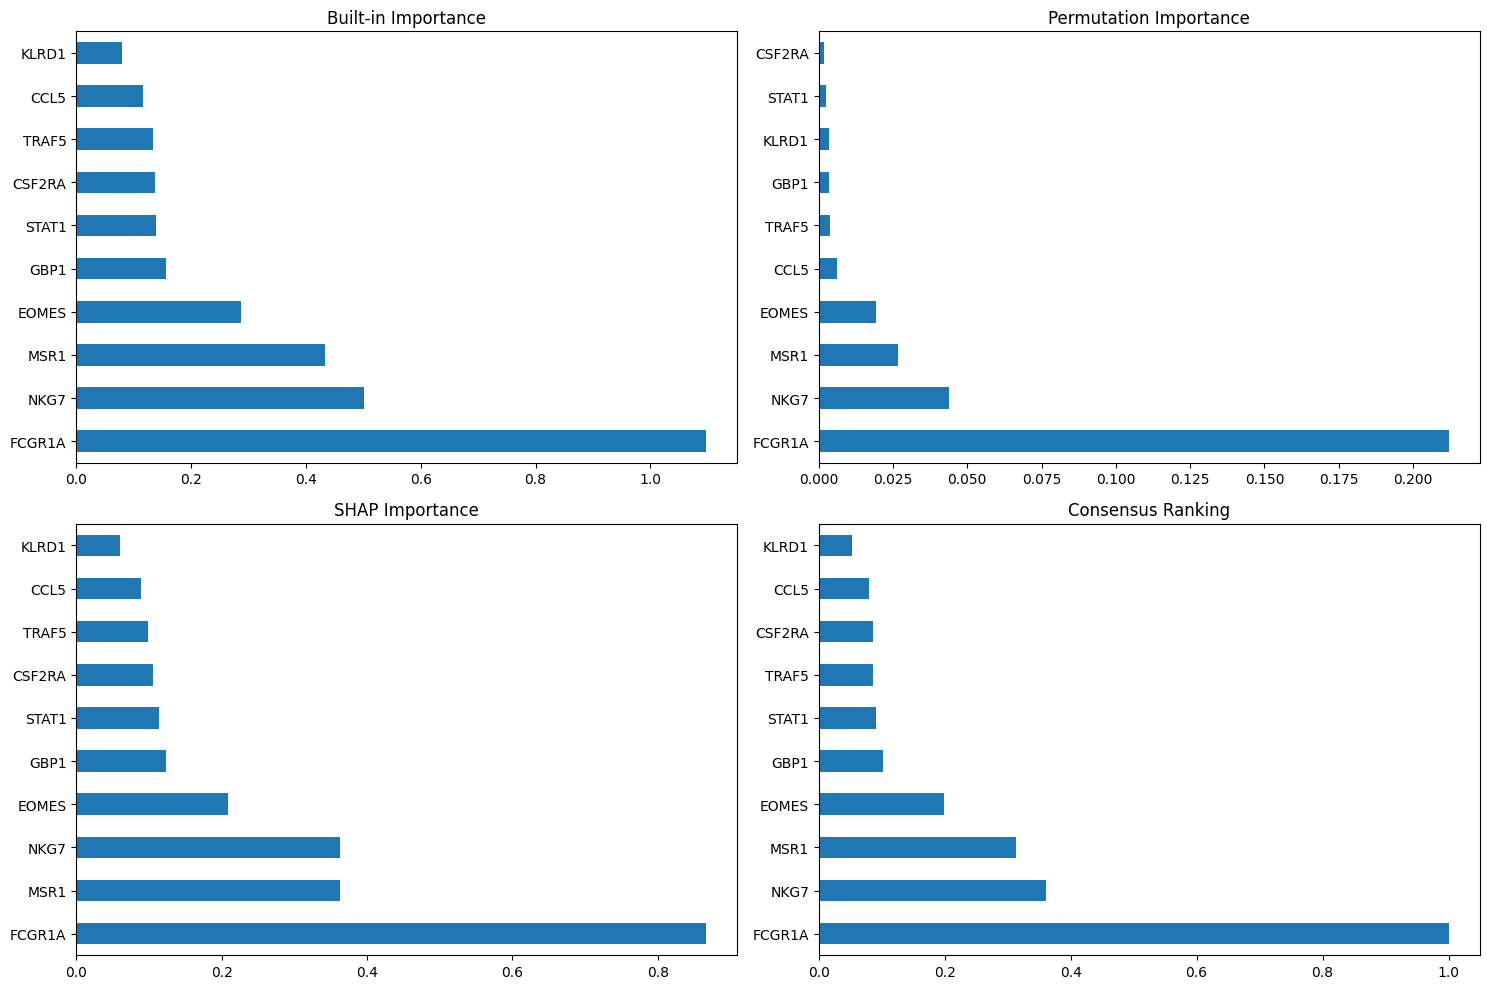

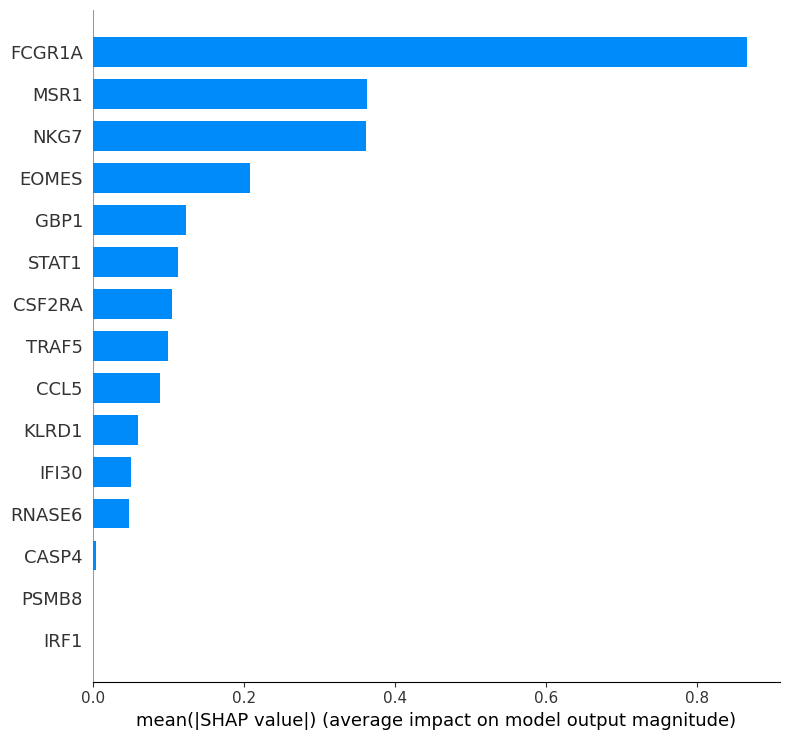

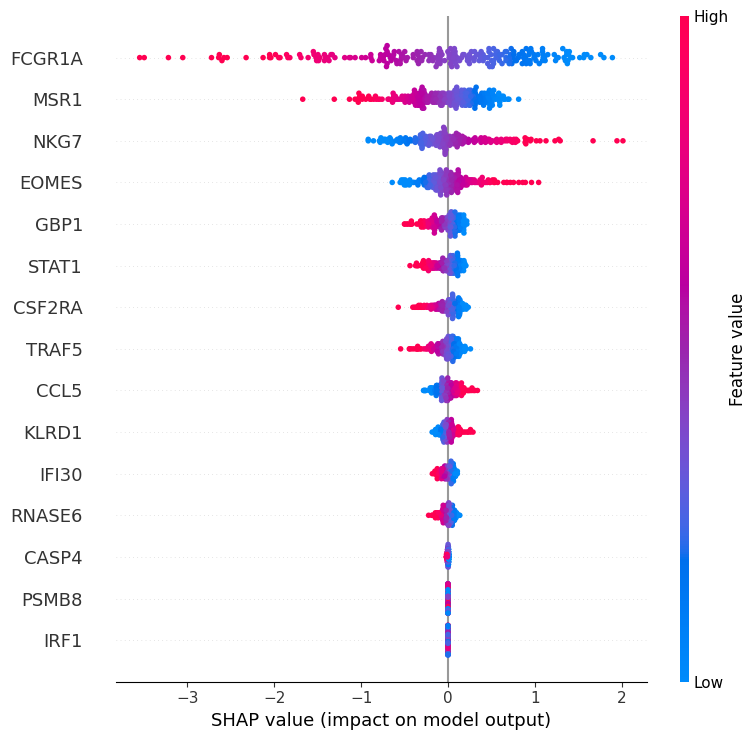

In [63]:
liver_lasso_features = get_feature_importances(data_liver, meta_liver, "classes", combined_gene_list, model_type="lasso")

### Kidney

In [48]:
data_kidney = read_file("../../data/GSE192444_kidney.csv", index=True)
meta_kidney = read_file('../../data/kidney_meta.xlsx', index=True)

In [51]:
overlap = [gene for gene in rats if gene in data_kidney.columns]
compare_models(data_kidney, meta_kidney, "group", overlap)

,model,accuracy_mean,accuracy_ci_lower,accuracy_ci_upper,std_acc,std_auc,auc_mean,auc_ci_lower,auc_ci_upper,train_test_gap
0,rndm,0.916667,0.892318,0.941015,0.037268,0.034074,0.969637,0.947376,0.991899,0.083333
1,svm,0.926667,0.905329,0.948004,0.032660,0.034039,0.965244,0.943006,0.987483,0.073333
2,lasso,0.926667,0.896178,0.957156,0.046667,0.032069,0.971231,0.950279,0.992183,0.028889


In [52]:
# each 3 way module performance
for i in range(1,7):
    file = f"../../results/module_comparison/three_way_conserved_genes_{i}.txt"
    gene_list = list(read_file(file)['Gene'])
    print(f"3 way combination {i}")
    three_way_performance = compare_models(data_kidney, meta_kidney, "group", gene_list)
    print(three_way_performance)
    print("\n")

3 way combination 1
   model  accuracy_mean  accuracy_ci_lower  accuracy_ci_upper   std_acc  \
0   rndm       0.886667           0.849966           0.923367  0.056174   
1    svm       0.860000           0.822532           0.897468  0.057349   
2  lasso       0.843333           0.817474           0.869193  0.039581   

    std_auc  auc_mean  auc_ci_lower  auc_ci_upper  train_test_gap  
0  0.039909  0.937896      0.911822      0.963970        0.113333  
1  0.046756  0.939800      0.909253      0.970347        0.069259  
2  0.030482  0.917798      0.897883      0.937713        0.007037  


3 way combination 2
   model  accuracy_mean  accuracy_ci_lower  accuracy_ci_upper   std_acc  \
0   rndm       0.850000           0.818819           0.881181  0.047726   
1    svm       0.796667           0.768356           0.824978  0.043333   
2  lasso       0.826667           0.799466           0.853867  0.041633   

    std_auc  auc_mean  auc_ci_lower  auc_ci_upper  train_test_gap  
0  0.042116  0.9

In [53]:
for i in range(1,4):
    file = f"../../results/module_comparison/conserved_group_{i}_genes.txt"
    gene_list = list(read_file(file)['Gene'])
    print(f"combination network {i}")
    two_way_performance = compare_models(data_kidney, meta_kidney, "group", gene_list)
    print(two_way_performance)
    print("\n")

combination network 1
   model  accuracy_mean  accuracy_ci_lower  accuracy_ci_upper   std_acc  \
0   rndm       0.903333           0.880597           0.926070  0.034801   
1    svm       0.886667           0.845117           0.928216  0.063596   
2  lasso       0.913333           0.883793           0.942874  0.045216   

    std_auc  auc_mean  auc_ci_lower  auc_ci_upper  train_test_gap  
0  0.048807  0.954316      0.922429      0.986204        0.096667  
1  0.042132  0.948113      0.920586      0.975639        0.113333  
2  0.040520  0.954816      0.928343      0.981289        0.009630  


combination network 2
   model  accuracy_mean  accuracy_ci_lower  accuracy_ci_upper   std_acc  \
0   rndm       0.700000           0.645774           0.754226  0.082999   
1    svm       0.703333           0.665051           0.741615  0.058595   
2  lasso       0.710000           0.677625           0.742375  0.049554   

    std_auc  auc_mean  auc_ci_lower  auc_ci_upper  train_test_gap  
0  0.054415 

In [54]:
# combined 3 way modules' performance
compare_models(data_kidney, meta_kidney, "group", combined_gene_list)

,model,accuracy_mean,accuracy_ci_lower,accuracy_ci_upper,std_acc,std_auc,auc_mean,auc_ci_lower,auc_ci_upper,train_test_gap
0,rndm,0.900000,0.878222,0.921778,0.033333,0.051111,0.952280,0.918888,0.985673,0.100000
1,svm,0.903333,0.871850,0.934817,0.048189,0.041008,0.948460,0.921669,0.975252,0.096667
2,lasso,0.916667,0.885486,0.947848,0.047726,0.036212,0.961193,0.937534,0.984851,0.007778


0.9166666666666667 0.9611928104575164
Top 10 features by consensus:
          builtin  permutation      shap  consensus
KLRD1    1.000000     1.000000  1.000000   1.000000
GBP4     0.618119     0.302815  0.631924   0.517619
PRF1     0.503983     0.171077  0.491587   0.388883
CXCL9    0.314331     0.069492  0.330742   0.238189
ENTPD1   0.142927     0.034228  0.129754   0.102303
APOL3    0.026936     0.002200  0.026618   0.018585
HLA-DMB  0.000000     0.000000  0.000000   0.000000
LCP2     0.000000     0.000000  0.000000   0.000000
CD53     0.000000     0.000000  0.000000   0.000000
CD44     0.000000     0.000000  0.000000   0.000000


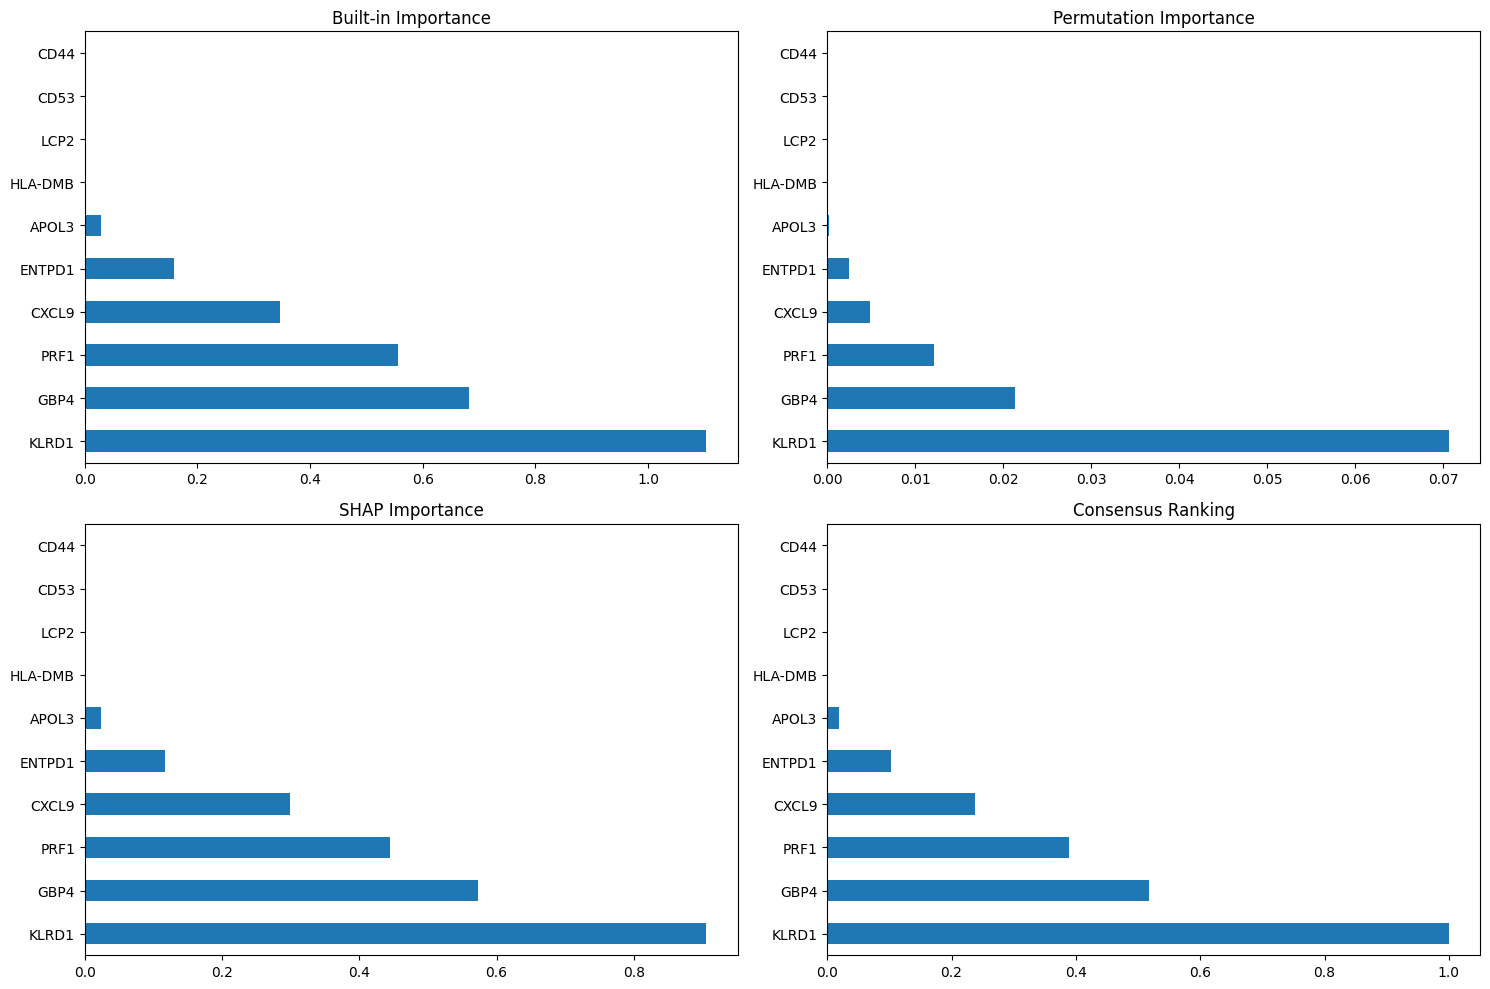

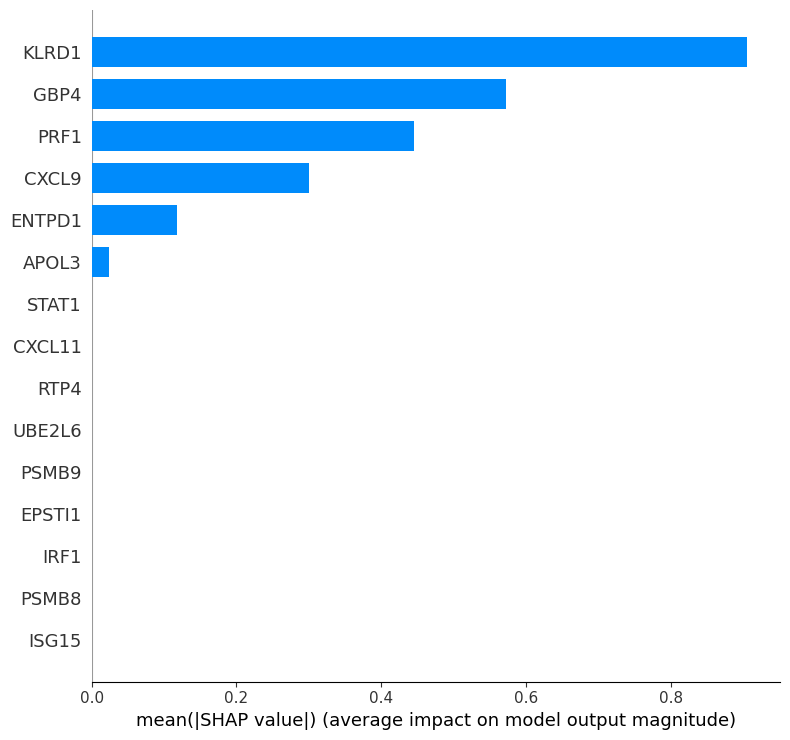

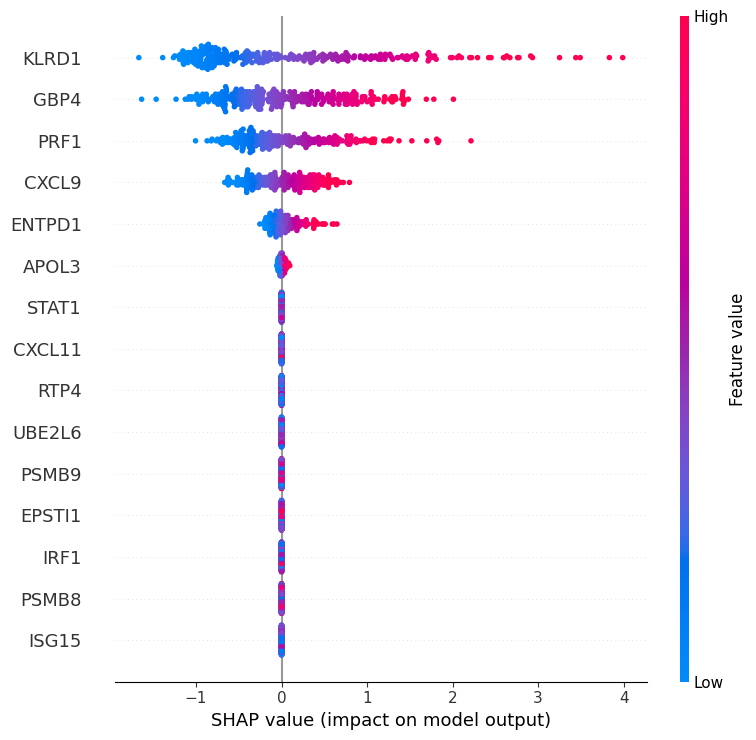

In [62]:
kidney_lasso_features = get_feature_importances(data_kidney, meta_kidney, "group", combined_gene_list, model_type="lasso")

### Heart

In [56]:
data_heart = read_file("../../data/GSE272655_heart.csv", index=True)
meta_heart = read_file('../../data/heart_meta.xlsx', index=True)

In [57]:
overlap = [gene for gene in rats if gene in data_heart.columns]
compare_models(data_heart, meta_heart, "group", overlap)

,model,accuracy_mean,accuracy_ci_lower,accuracy_ci_upper,std_acc,std_auc,auc_mean,auc_ci_lower,auc_ci_upper,train_test_gap
0,rndm,0.941758,0.906615,0.976901,0.053790,0.037102,0.971250,0.947010,0.995490,0.058242
1,svm,0.935165,0.891088,0.979241,0.067464,0.033840,0.964722,0.942613,0.986831,0.064835
2,lasso,0.920879,0.872180,0.969578,0.074539,0.055000,0.960000,0.924067,0.995933,0.025607


In [58]:
# each 3 way module performance
for i in range(1,7):
    file = f"../../results/module_comparison/three_way_conserved_genes_{i}.txt"
    gene_list = list(read_file(file)['Gene'])
    print(f"3 way combination {i}")
    three_way_performance = compare_models(data_heart, meta_heart, "group", gene_list)
    print(three_way_performance)
    print("\n")

3 way combination 1
   model  accuracy_mean  accuracy_ci_lower  accuracy_ci_upper   std_acc  \
0   rndm       0.855495           0.793671           0.917318  0.094628   
1    svm       0.846703           0.807169           0.886238  0.060512   
2  lasso       0.876374           0.828960           0.923787  0.072571   

    std_auc  auc_mean  auc_ci_lower  auc_ci_upper  train_test_gap  
0  0.050293  0.955972      0.923114      0.988830        0.144505  
1  0.051106  0.949722      0.916333      0.983111        0.132204  
2  0.065876  0.931389      0.888350      0.974428        0.019817  


3 way combination 2
   model  accuracy_mean  accuracy_ci_lower  accuracy_ci_upper   std_acc  \
0   rndm       0.882967           0.825980           0.939954  0.087224   
1    svm       0.833516           0.770988           0.896045  0.095707   
2  lasso       0.884066           0.831985           0.936147  0.079716   

    std_auc  auc_mean  auc_ci_lower  auc_ci_upper  train_test_gap  
0  0.070163  0.9

In [59]:
for i in range(1,4):
    file = f"../../results/module_comparison/conserved_group_{i}_genes.txt"
    gene_list = list(read_file(file)['Gene'])
    print(f"combination network {i}")
    two_way_performance = compare_models(data_heart, meta_heart, "group", gene_list)
    print(two_way_performance)
    print("\n")

combination network 1
   model  accuracy_mean  accuracy_ci_lower  accuracy_ci_upper   std_acc  \
0   rndm       0.926923           0.890738           0.963108  0.055386   
1    svm       0.884066           0.820670           0.947462  0.097035   
2  lasso       0.906593           0.843881           0.969306  0.095989   

    std_auc  auc_mean  auc_ci_lower  auc_ci_upper  train_test_gap  
0  0.031623    0.9750      0.954340      0.995660        0.073077  
1  0.062300    0.9425      0.901798      0.983202        0.115934  
2  0.050062    0.9575      0.924793      0.990207        0.038260  


combination network 2
   model  accuracy_mean  accuracy_ci_lower  accuracy_ci_upper   std_acc  \
0   rndm       0.855495           0.789712           0.921277  0.100687   
1    svm       0.862088           0.817817           0.906358  0.067761   
2  lasso       0.803297           0.751754           0.854839  0.078892   

    std_auc  auc_mean  auc_ci_lower  auc_ci_upper  train_test_gap  
0  0.081212 

In [60]:
# combined 3 way modules' performance
compare_models(data_heart, meta_heart, "group", combined_gene_list)

,model,accuracy_mean,accuracy_ci_lower,accuracy_ci_upper,std_acc,std_auc,auc_mean,auc_ci_lower,auc_ci_upper,train_test_gap
0,rndm,0.926923,0.890738,0.963108,0.055386,0.035355,0.975000,0.951901,0.998099,0.073077
1,svm,0.912637,0.867104,0.958171,0.069694,0.042402,0.961944,0.934242,0.989647,0.087363
2,lasso,0.913187,0.867587,0.958786,0.069795,0.046286,0.959722,0.929482,0.989962,0.021130


0.9131868131868132 0.9597222222222221
Top 10 features by consensus:
         builtin  permutation      shap  consensus
KLRD1   1.000000     1.000000  1.000000   1.000000
SAMD3   0.221667     0.032343  0.217896   0.157302
IRF8    0.167533     0.028403  0.169161   0.121699
CXCL9   0.149800     0.022328  0.164689   0.112272
CXCL11  0.132835     0.015104  0.148513   0.098818
RUNX3   0.128826     0.015597  0.129708   0.091377
HCP5    0.104232     0.020358  0.098872   0.074487
ANXA1   0.000000     0.000000  0.000000   0.000000
ADCY7   0.000000     0.000000  0.000000   0.000000
AIF1    0.000000     0.000000  0.000000   0.000000


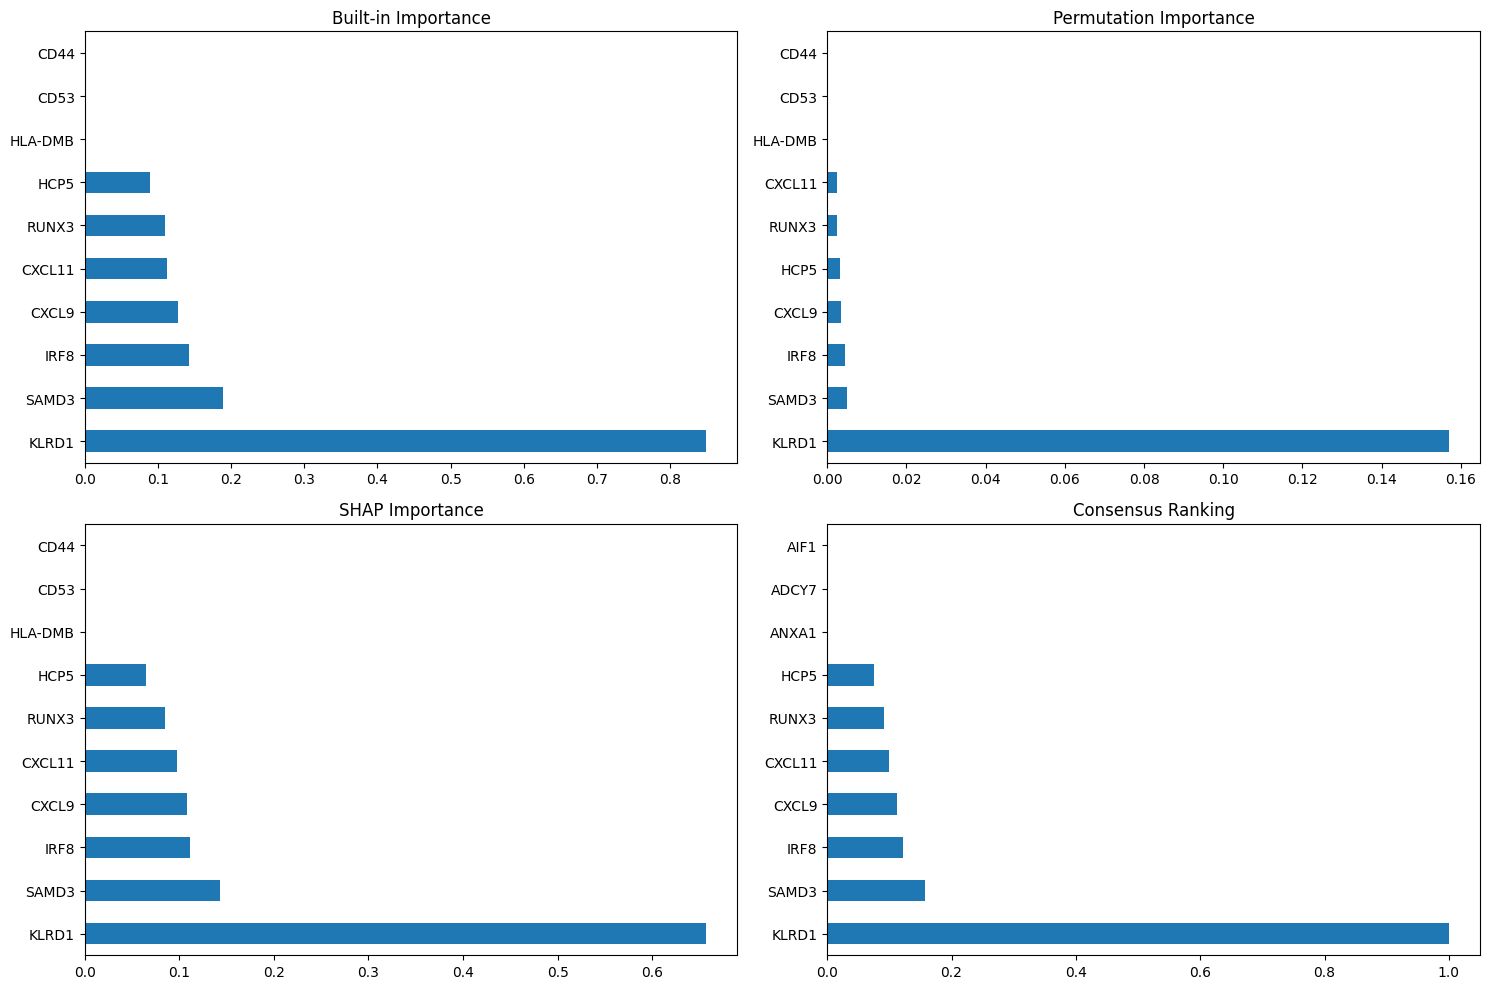

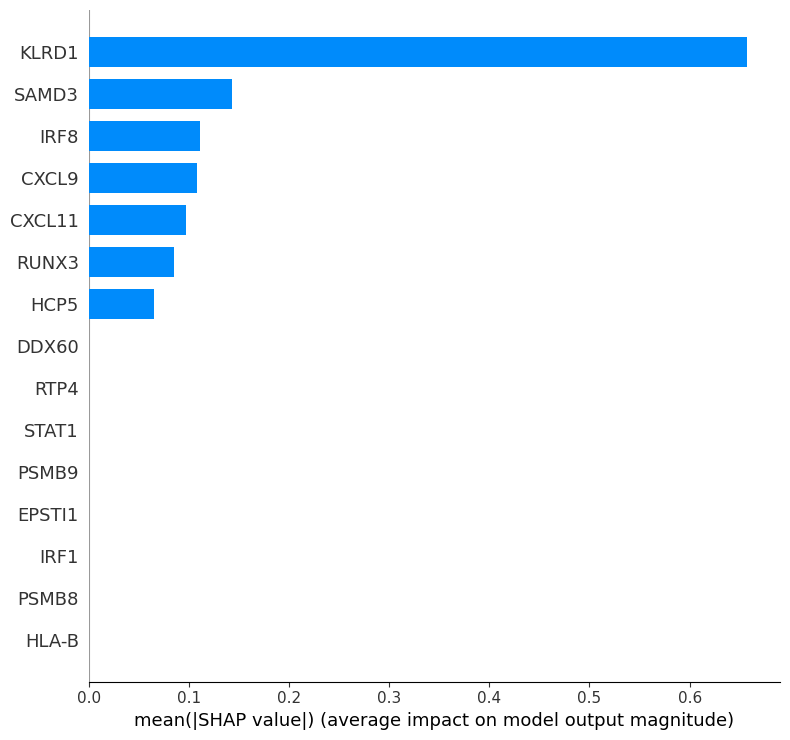

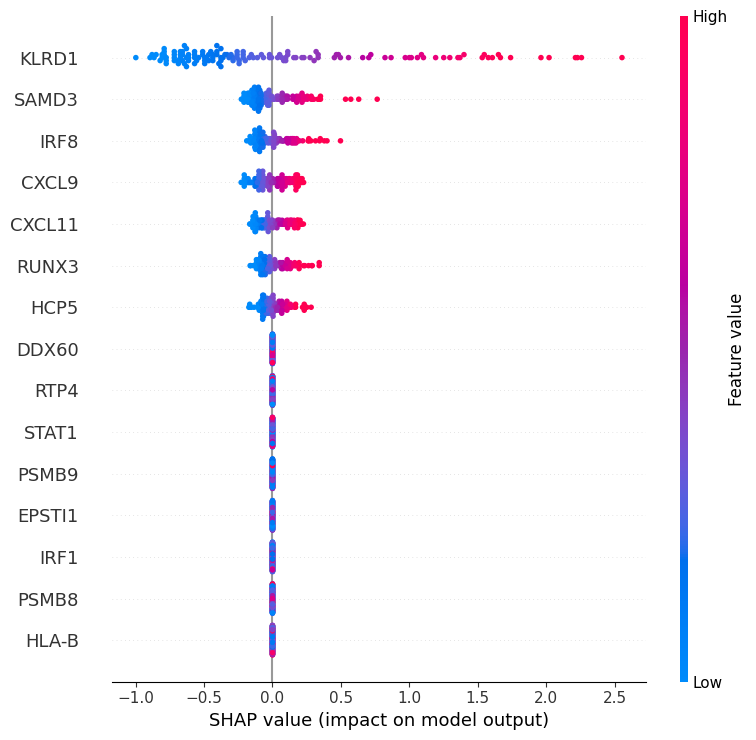

In [61]:
heart_lasso_features = get_feature_importances(data_heart, meta_heart, "group", combined_gene_list, model_type="lasso")

## Consensus Analysis (Feature Importance)

In [64]:
df = pd.DataFrame({
    'liver_lasso': liver_lasso_features.index,
    "kidney_lasso": kidney_lasso_features.index,
    'heart_lasso': heart_lasso_features.index
})
print(df.head(20))

   liver_lasso kidney_lasso heart_lasso
0       FCGR1A        KLRD1       KLRD1
1         NKG7         GBP4       SAMD3
2         MSR1         PRF1        IRF8
3        EOMES        CXCL9       CXCL9
4         GBP1       ENTPD1      CXCL11
5        STAT1        APOL3       RUNX3
6        TRAF5      HLA-DMB        HCP5
7       CSF2RA         LCP2       ANXA1
8         CCL5         CD53       ADCY7
9        KLRD1         CD44        AIF1
10      RNASE6         NAGK        AIM2
11       IFI30         GMFG       ALOX5
12       CASP4        VSIG4      BTN3A1
13      BCL11B         CTSS      BTN3A2
14        BIN2        ITGB2      BTN3A3
15      BTN3A1        FOLR2        C1QA
16        C1QB         PLEK        C1QB
17        C1QC        ADCY7        C1QC
18     ARHGDIB       TYROBP    C1orf162
19      BTN3A2         C1QA       C3AR1


In [65]:
# lasso
all_genes = set(liver_lasso_features.index) | set(kidney_lasso_features.index) | set(heart_lasso_features.index)

consensus_df = pd.DataFrame(index=list(all_genes))
consensus_df['liver'] = liver_lasso_features
consensus_df['kidney'] = kidney_lasso_features  
consensus_df['heart'] = heart_lasso_features

consensus_df = consensus_df.fillna(0)
avg_lasso_consensus = consensus_df.mean(axis=1).sort_values(ascending=False)
print(avg_lasso_consensus.head(20))

KLRD1     0.684527
FCGR1A    0.333333
GBP4      0.172838
PRF1      0.129926
NKG7      0.120457
CXCL9     0.117118
MSR1      0.104665
EOMES     0.066276
SAMD3     0.052732
IRF8      0.040865
ENTPD1    0.034399
GBP1      0.033757
CXCL11    0.033237
RUNX3     0.030757
STAT1     0.030190
TRAF5     0.028582
CSF2RA    0.028551
CCL5      0.026686
HCP5      0.025127
RNASE6    0.012979
dtype: float64


#### Finding biomarker cut-off

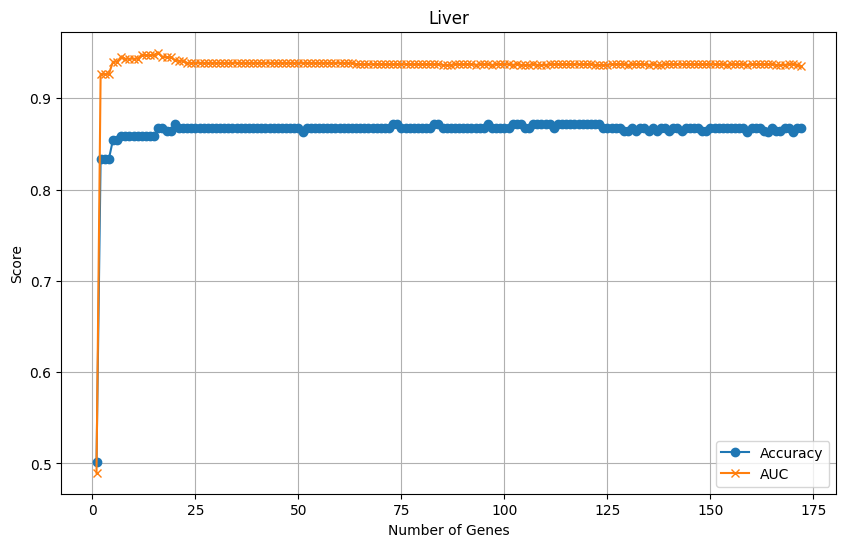

In [66]:
genes = []
accs, aucs = [], []
for i in range(172):
    # run the auc_acc function for each additional gene
    acc, auc, model, feature_importance = avg_acc_auc(data_liver[avg_lasso_consensus.index.tolist()[:i+1]], meta_liver["classes"], "lasso")
    # print(f"Top {i+1} genes - Accuracy: {np.mean(acc)}, AUC: {np.mean(auc)}")
    accs.append(np.mean(acc))
    aucs.append(np.mean(auc))

plt.figure(figsize=(10, 6))
plt.plot(range(1, 173), accs, marker='o', label='Accuracy')
plt.plot(range(1, 173), aucs, marker='x', label='AUC')
plt.xlabel('Number of Genes')
plt.ylabel('Score')
plt.title('Liver')
plt.legend()
plt.grid()

In [68]:
# best acc for 16 genes
acc, auc, model, feature_importance = avg_acc_auc(data_liver[avg_lasso_consensus.index.tolist()[:16]], meta_liver["classes"], "lasso")
print(np.mean(acc))
for i in zip(avg_lasso_consensus.index.tolist()[:20],feature_importance):
    print(i)

0.8677536231884059
('KLRD1', np.float64(0.09025890158454314))
('FCGR1A', np.float64(1.1991126660877813))
('GBP4', np.float64(0.0))
('PRF1', np.float64(0.0))
('NKG7', np.float64(0.5919311815987753))
('CXCL9', np.float64(0.0))
('MSR1', np.float64(0.5074206897111139))
('EOMES', np.float64(0.3085181833368518))
('SAMD3', np.float64(0.0))
('IRF8', np.float64(0.0))
('ENTPD1', np.float64(0.0))
('GBP1', np.float64(0.13493854949700626))
('CXCL11', np.float64(0.0))
('RUNX3', np.float64(0.0))
('STAT1', np.float64(0.13719449671352016))
('TRAF5', np.float64(0.21231281365987248))


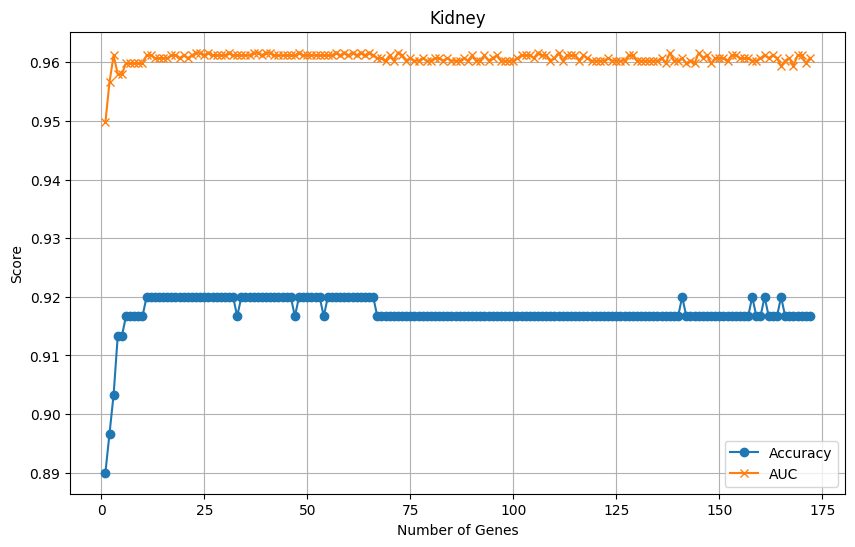

In [69]:
genes = []
accs, aucs = [], []
for i in range(172):
    # run the auc_acc function for each additional gene
    acc, auc, model, feature_importance = avg_acc_auc(data_kidney[avg_lasso_consensus.index.tolist()[:i+1]], meta_kidney["group"], "lasso")
    # print(f"Top {i+1} genes - Accuracy: {np.mean(acc)}, AUC: {np.mean(auc)}")
    accs.append(np.mean(acc))
    aucs.append(np.mean(auc))

plt.figure(figsize=(10, 6))
plt.plot(range(1, 173), accs, marker='o', label='Accuracy')
plt.plot(range(1, 173), aucs, marker='x', label='AUC')
plt.xlabel('Number of Genes')
plt.ylabel('Score')
plt.title('Kidney')
plt.legend()
plt.grid()

# plt.savefig('figures/kidney_model_performance_vs_num_genes.svg', dpi=600)

In [72]:
# best acc for 20 genes
acc, auc, model, feature_importance = avg_acc_auc(data_kidney[avg_lasso_consensus.index.tolist()[:20]], meta_kidney["group"], "lasso")
print(np.mean(acc))
for i in zip(avg_lasso_consensus.index.tolist()[:20],feature_importance):
    print(i)

0.9200000000000002
('KLRD1', np.float64(0.938726842091085))
('FCGR1A', np.float64(0.0))
('GBP4', np.float64(0.6412200742371477))
('PRF1', np.float64(0.8056533283008316))
('NKG7', np.float64(0.0))
('CXCL9', np.float64(0.1307349309418524))
('MSR1', np.float64(0.0))
('EOMES', np.float64(0.0))
('SAMD3', np.float64(0.0))
('IRF8', np.float64(0.0))
('ENTPD1', np.float64(0.3014059439247434))
('GBP1', np.float64(0.0))
('CXCL11', np.float64(0.12354619441704173))
('RUNX3', np.float64(0.0))
('STAT1', np.float64(0.0))
('TRAF5', np.float64(0.0))
('CSF2RA', np.float64(0.0))
('CCL5', np.float64(0.0))
('HCP5', np.float64(0.0))
('RNASE6', np.float64(0.0))


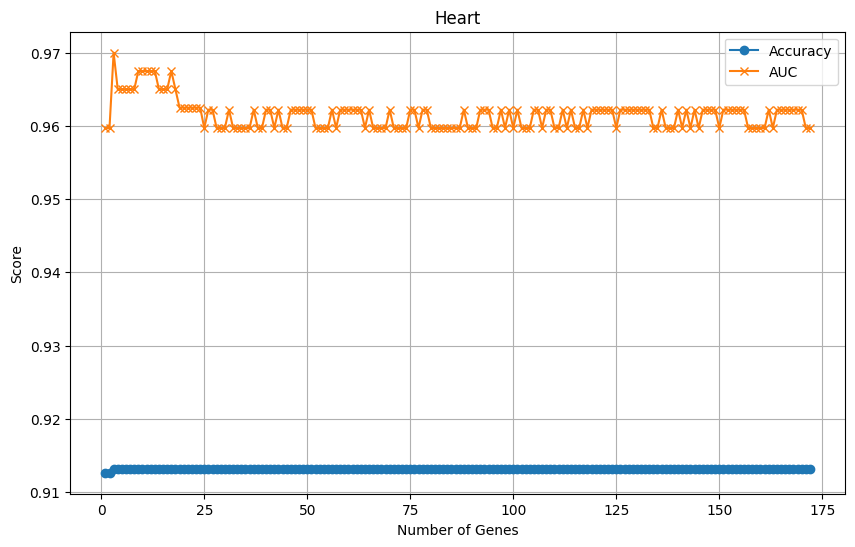

In [73]:
genes = []
accs, aucs = [], []
for i in range(172):
    # run the auc_acc function for each additional gene
    acc, auc, model, feature_importance = avg_acc_auc(data_heart[avg_lasso_consensus.index.tolist()[:i+1]], meta_heart["group"], "lasso")
    # print(f"Top {i+1} genes - Accuracy: {np.mean(acc)}, AUC: {np.mean(auc)}")
    accs.append(np.mean(acc))
    aucs.append(np.mean(auc))

plt.figure(figsize=(10, 6))
plt.plot(range(1, 173), accs, marker='o', label='Accuracy')
plt.plot(range(1, 173), aucs, marker='x', label='AUC')
plt.xlabel('Number of Genes')
plt.ylabel('Score')
plt.title('Heart')
plt.legend()
plt.grid()

# plt.savefig('figures/heart_model_performance_vs_num_genes.svg', dpi=600)

In [74]:
# best acc for 20 genes
acc, auc, model, feature_importance = avg_acc_auc(data_heart[avg_lasso_consensus.index.tolist()[:20]], meta_heart["group"], "lasso")
print(np.mean(acc))
for i in zip(avg_lasso_consensus.index.tolist()[:20],feature_importance):
    print(i)

0.9131868131868132
('KLRD1', np.float64(0.8552641361026695))
('FCGR1A', np.float64(0.0))
('GBP4', np.float64(0.0))
('PRF1', np.float64(0.0))
('NKG7', np.float64(0.0))
('CXCL9', np.float64(0.09863853170888029))
('MSR1', np.float64(0.0))
('EOMES', np.float64(0.0))
('SAMD3', np.float64(0.18996975142705938))
('IRF8', np.float64(0.15741773815511387))
('ENTPD1', np.float64(0.0))
('GBP1', np.float64(0.0))
('CXCL11', np.float64(0.13020945705319786))
('RUNX3', np.float64(0.10160923842372932))
('STAT1', np.float64(0.0))
('TRAF5', np.float64(0.0))
('CSF2RA', np.float64(0.0))
('CCL5', np.float64(0.0))
('HCP5', np.float64(0.08733693163193196))
('RNASE6', np.float64(0.0))


In [75]:
avg_lasso_consensus[:20]

KLRD1     0.684527
FCGR1A    0.333333
GBP4      0.172838
PRF1      0.129926
NKG7      0.120457
CXCL9     0.117118
MSR1      0.104665
EOMES     0.066276
SAMD3     0.052732
IRF8      0.040865
ENTPD1    0.034399
GBP1      0.033757
CXCL11    0.033237
RUNX3     0.030757
STAT1     0.030190
TRAF5     0.028582
CSF2RA    0.028551
CCL5      0.026686
HCP5      0.025127
RNASE6    0.012979
dtype: float64

In [76]:
df = {"genes": [], "in_rats":[]}
for i in avg_lasso_consensus[:20].index:
    df["genes"].append(i)
    df["in_rats"].append(i in rats)

df = pd.DataFrame(df)
df

,genes,in_rats
0,KLRD1,True
1,FCGR1A,True
2,GBP4,True
3,PRF1,True
4,NKG7,True
5,CXCL9,True
6,MSR1,False
7,EOMES,True
8,SAMD3,False
9,IRF8,False
